## Mount & Path

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
 
# path_file  = '/content/drive/MyDrive/tesisugm/' #google colab
path_file = ''  # local

KOMPOSISI  = "effect_size"

## Load Features Module

In [2]:
import importlib.util, sys
 
# MODULE_PATH = "/content/drive/MyDrive/tesisugm/no-leakage/features.py"
MODULE_PATH = "features.py"

spec    = importlib.util.spec_from_file_location("features", MODULE_PATH)
features = importlib.util.module_from_spec(spec)
sys.modules["features"] = features
spec.loader.exec_module(features)
print("Features file   :", features.__file__)
print("Features version:", features.FEATURES_VERSION)

Features file   : features.py
Features version: Shami Extractor


## Imports

In [3]:
import os, gc, warnings, hashlib, itertools, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.sparse import hstack, csr_matrix, issparse
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, normalize
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report, confusion_matrix,
                                      silhouette_score)
from features import ShamiFeatureExtractor, clean_noise, clean_char
import scipy.stats as stats
from scipy.stats import wilcoxon
from sklearn.utils import resample

# Set environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress all warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# Specific sklearn warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', module='sklearn.utils.validation')

# Your existing code
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', message='X does not have valid feature names')
 
warnings.filterwarnings("ignore")
print("Libraries loaded.")
 

Libraries loaded.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# ── Global Theme ────────────────────────────────────────────
PALETTE   = ["#2D4A7A", "#4A90C4", "#6DB8A8", "#C4956A"]  # Jordan, Lebanon, Palestine, Syria
BG_COLOR  = "#F8F9FB"
CARD_COLOR= "#FFFFFF"
TEXT_DARK = "#1A2640"
TEXT_MID  = "#4A5568"
TEXT_LIGHT= "#8A97AA"
GRID_COLOR= "#E8ECF1"

def set_global_style():
    plt.rcParams.update({
        "figure.facecolor"  : BG_COLOR,
        "axes.facecolor"    : CARD_COLOR,
        "axes.edgecolor"    : GRID_COLOR,
        "axes.linewidth"    : 0.8,
        "axes.grid"         : True,
        "grid.color"        : GRID_COLOR,
        "grid.linewidth"    : 0.6,
        "grid.alpha"        : 0.8,
        "text.color"        : TEXT_DARK,
        "axes.labelcolor"   : TEXT_MID,
        "xtick.color"       : TEXT_MID,
        "ytick.color"       : TEXT_MID,
        "xtick.labelsize"   : 10,
        "ytick.labelsize"   : 10,
        "axes.labelsize"    : 11,
        "axes.titlesize"    : 13,
        "axes.titleweight"  : "bold",
        "axes.titlepad"     : 12,
        "font.family"       : "sans-serif",
        # "font.sans-serif"   : ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
    })
set_global_style()

print("✅ Global style set!")

✅ Global style set!


## Inisiasi Path

In [5]:
# ROOT
BASE_DIR = os.path.join(path_file, "artifacts")

# GLOBAL SAVE
SAVE_DIR = os.path.join(BASE_DIR, "output")
KOMPOSISI_DIR = os.path.join(BASE_DIR, KOMPOSISI)
MODEL_DIR = os.path.join(KOMPOSISI_DIR, "model")
IMAGE_DIR = os.path.join(KOMPOSISI_DIR, "image")
DOCS_DIR  = os.path.join(KOMPOSISI_DIR, "docs")

ALGORITMA = ""  
komposisi_effect = ""
folder_name = f"{ALGORITMA}_{komposisi_effect}"

EFFECT_DIR = os.path.join(BASE_DIR, folder_name)
model_name = f"model_{ALGORITMA}_{komposisi_effect}.pkl"
EFFECT_MODEL_DIR = os.path.join(EFFECT_DIR, "model")
MODEL_PATH = os.path.join(EFFECT_MODEL_DIR, model_name)

# CREATE ALL
for d in [SAVE_DIR, KOMPOSISI_DIR, MODEL_DIR, IMAGE_DIR, DOCS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Semua path berhasil diinisialisasi!")

✅ Semua path berhasil diinisialisasi!


In [6]:
def save_and_show(name):
    path = os.path.join(IMAGE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

def global_image(name):
    path = os.path.join(SAVE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

## Data Preparation

In [7]:
df = pd.read_csv(f'../{path_file}dataset/shami_preprocessed_dataset_raw.csv')
df = (
    df.dropna(subset=["text", "label"])
      .rename(columns={"label": "country"})
)
df["clean_word"] = df["text"].apply(clean_noise)
df["clean_char"] = df["text"].apply(clean_char)
 
try:    display(df.head())
except: print(df.head())
display(df['country'].value_counts(normalize=True))

,text,country,clean_word,clean_char
0,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,Palestine,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...
1,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,Palestine,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...
2,اعملي اللي عليكي لوجه الله,Palestine,اعملي اللي عليكي لوجه الله,اعملي اللي عليكي لوجه الله
3,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,Palestine,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها
4,و هيا واياه بتزوجو هه,Palestine,و هيا واياه بتزوجو هه,و هيا واياه بتزوجو هه


country
Syria        0.569973
Lebanon      0.163464
Palestine    0.160641
Jordan       0.105922
Name: proportion, dtype: float64

### Class distribution plot 

🖼️ Saved: artifacts/output/class_distribution.png


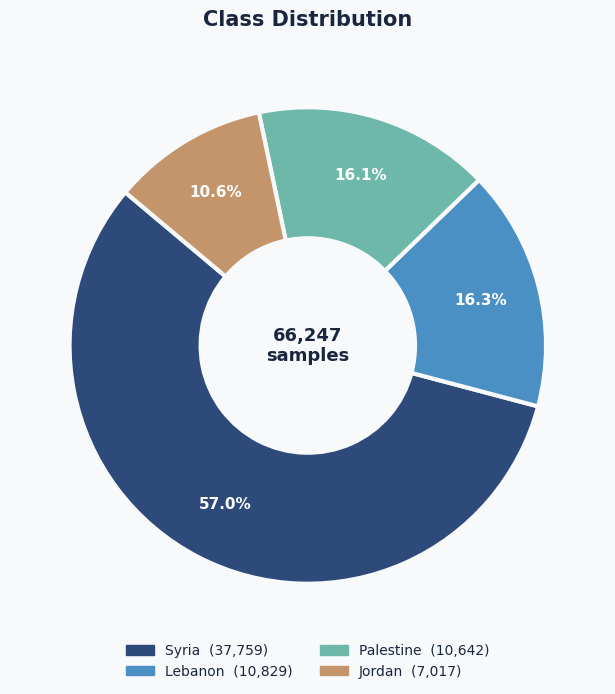

In [8]:
class_dist = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
wedges, texts, autotexts = ax.pie(
    class_dist,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=3),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Centre label
ax.text(0, 0, f"{class_dist.sum():,}\nsamples",
        ha='center', va='center', fontsize=13,
        fontweight='bold', color=TEXT_DARK)

# Legend
legend_labels = [f"{c}  ({v:,})" for c, v in class_dist.items()]
patches = [mpatches.Patch(color=PALETTE[i], label=legend_labels[i])
           for i in range(len(class_dist))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          ncol=2, frameon=False, fontsize=10)

ax.set_title("Class Distribution", fontsize=15, fontweight='bold',
             color=TEXT_DARK, pad=16)
fig.tight_layout()
global_image("class_distribution")

### Split

In [9]:
X = df[["text", "clean_word", "clean_char"]]
y = df["country"]
 
le          = LabelEncoder()
y_encoded   = le.fit_transform(y)
label_names = le.classes_
label_mapping   = {label: idx  for idx, label in enumerate(label_names)}
class_name_map  = {i: name     for i, name   in enumerate(label_names)}
print("Label mapping:", label_mapping)
 
from collections import Counter
 
def print_class_distribution(y_data, title):
    counter = Counter(y_data)
    print(f"\n=== {title} ===")
    total = len(y_data)
    for cls_id in sorted(counter.keys()):
        cls_name = class_name_map[cls_id]
        count    = counter[cls_id]
        print(f"{cls_id} ({cls_name}) : {count} ({count/total*100:.2f}%)")
    print("Total :", total)
 
print_class_distribution(y_encoded, "BEFORE SPLIT")
 
X_train_full, X_test,  y_train_full, y_test  = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    stratify=y_train_full, random_state=42)
 
print_class_distribution(y_train, "TRAIN SET")
print_class_distribution(y_val,   "VALIDATION SET")
print_class_distribution(y_test,  "TEST SET")

Label mapping: {'Jordan': 0, 'Lebanon': 1, 'Palestine': 2, 'Syria': 3}

=== BEFORE SPLIT ===
0 (Jordan) : 7017 (10.59%)
1 (Lebanon) : 10829 (16.35%)
2 (Palestine) : 10642 (16.06%)
3 (Syria) : 37759 (57.00%)
Total : 66247

=== TRAIN SET ===
0 (Jordan) : 4210 (10.59%)
1 (Lebanon) : 6498 (16.35%)
2 (Palestine) : 6385 (16.06%)
3 (Syria) : 22655 (57.00%)
Total : 39748

=== VALIDATION SET ===
0 (Jordan) : 1053 (10.60%)
1 (Lebanon) : 1624 (16.34%)
2 (Palestine) : 1596 (16.06%)
3 (Syria) : 5664 (57.00%)
Total : 9937

=== TEST SET ===
0 (Jordan) : 1754 (10.59%)
1 (Lebanon) : 2707 (16.34%)
2 (Palestine) : 2661 (16.07%)
3 (Syria) : 9440 (57.00%)
Total : 16562


## Feature Extraction

In [10]:
CHI2_PCT             = 0.015
MI_PCT23             = 0.010
MI_PCT45             = 0.015
USE_OOF_INTERACTION = True   # flag diteruskan ke ShamiFeatureExtractor
 
split_hash = hashlib.md5(pd.util.hash_pandas_object(X_train["text"]).values).hexdigest()[:10]
base_signature = f"{features.FEATURES_VERSION}_{split_hash}"
base_cache_dir = os.path.join(path_file, "cache", base_signature)
os.makedirs(base_cache_dir, exist_ok=True)
 
feat_cache_key = (
    f"chi2_{CHI2_PCT}_mi23_{MI_PCT23}_mi45_{MI_PCT45}"
    f"_oof_inter_{int(USE_OOF_INTERACTION)}"
)
data_hash = hashlib.md5(df["text"].str.cat().encode()).hexdigest()[:8]

feat_cache_dir = os.path.join(
    base_cache_dir,
    feat_cache_key,
    data_hash
)

os.makedirs(feat_cache_dir, exist_ok=True)
print("Base signature :", base_signature)
print("Feat cache dir :", feat_cache_dir)
 
feat_path = os.path.join(base_cache_dir, "feature_extractor.pkl")
if os.path.exists(feat_path):
    print("✅ Loading base extractor...")
    feat = joblib.load(feat_path)
else:
    print("⚙️ Building base extractor (MI fit bisa makan waktu 2-5 menit)...")
    feat = ShamiFeatureExtractor(
        chi2_pct=CHI2_PCT,
        mi_pct23=MI_PCT23,
        mi_pct45=MI_PCT45,
        use_oof_lr=True,
        use_oof_interaction=USE_OOF_INTERACTION, 
    )
    feat.fit(X_train, y_train) 
    joblib.dump(feat, feat_path)
print("Base extractor ready.")

Base signature : Shami Extractor_0890ac2785
Feat cache dir : cache/Shami Extractor_0890ac2785/chi2_0.015_mi23_0.01_mi45_0.015_oof_inter_1/6ace3dc3
✅ Loading base extractor...
Base extractor ready.


### Update k

In [11]:
feat.update_chi2_pct(CHI2_PCT)
feat.update_mi_pct(new_pct23=MI_PCT23, new_pct45=MI_PCT45)
 
# ---- Info dimensi ----
print("\nMI info     :", feat.mi_info)
print("Block sizes :", feat.block_sizes)

[update] chi2_pct=1.50% -> chi2_k=2,420
[update] mi_pct23=1.00% -> mi_k23=500
[update] mi_pct45=1.50% -> mi_k45=2,650

MI info     : {'chi2_pct': 0.015, 'chi2_k_eff': 2420, 'mi_pct23': 0.01, 'mi_k23_eff': 500, 'char23_vocab': 10964, 'char23_selected': 500, 'mi_pct45': 0.015, 'mi_k45_eff': 2650, 'char45_vocab': 176676, 'char45_selected': 2650}
Block sizes : {'lexical': 2420, 'char_mi23': 500, 'char_mi45': 2650, 'doc_stats': 7, 'stopword': 2, 'morph': 26, 'morph_inter': 8, 'colloc_dom': 1, 'nbsvm': 4, 'oof_lr': 8, 'oof_svm': 8, 'oof_interactions': 10}


### Lexical Info

In [12]:
dims = {
    "tfidf_wL_uni": len(feat.tfidf_wL_uni.vocabulary_),
    "tfidf_wL_23" : len(feat.tfidf_wL_23.vocabulary_),
    "tfidf_wA_uni": len(feat.tfidf_wA_uni.vocabulary_),
    "tfidf_wA_23" : len(feat.tfidf_wA_23.vocabulary_),
    "tfidf_char"  : len(feat.tfidf_char.vocabulary_),
    "bm25_word"   : len(feat.bm25w.cv.vocabulary_),
    "bm25_char"   : len(feat.bm25c.cv.vocabulary_),
}
print("\n==============================")
print("LEXICAL FEATURES BEFORE CHI2")
print("==============================")
for k, v in dims.items():
    print(f"{k:15s}: {v:,}")
print(f"\nLEXICAL total  : {sum(dims.values()):,}")
 
ranges = {}
start  = 0
for name, size in dims.items():
    ranges[name] = (start, start + size)
    start += size
counts = {k: 0 for k in dims}
for c in feat._chi2_cols:
    for name, (s, e) in ranges.items():
        if s <= c < e:
            counts[name] += 1
            break
print("\n==============================")
print("LEXICAL FEATURES AFTER CHI2")
print("==============================")
for k, v in counts.items():
    print(f"{k:15s}: {v:,}")
print(f"\nTotal chi2 selected: {len(feat._chi2_cols):,}")


LEXICAL FEATURES BEFORE CHI2
tfidf_wL_uni   : 19,234
tfidf_wL_23    : 19,234
tfidf_wA_uni   : 19,226
tfidf_wA_23    : 19,226
tfidf_char     : 34,631
bm25_word      : 40,562
bm25_char      : 9,272

LEXICAL total  : 161,385

LEXICAL FEATURES AFTER CHI2
tfidf_wL_uni   : 115
tfidf_wL_23    : 115
tfidf_wA_uni   : 115
tfidf_wA_23    : 115
tfidf_char     : 843
bm25_word      : 316
bm25_char      : 801

Total chi2 selected: 2,420


In [13]:
print("\n==============================")
print("CHAR FEATURES BEFORE MI")
print("==============================")

print(f"char_2_3 vocab: {feat._X_char23_tr.shape[1]:,}")
print(f"char_4_5 vocab: {feat._X_char45_tr.shape[1]:,}")
print(f"Total char    : {feat._X_char23_tr.shape[1] + feat._X_char45_tr.shape[1]:,}")

print("\n==============================")
print("CHAR FEATURES AFTER MI")
print("==============================")

print(f"char_mi23: {feat._mi_sel23.n_selected:,}")
print(f"char_mi45: {feat._mi_sel45.n_selected:,}")
print(f"Total MI  : {feat._mi_sel23.n_selected + feat._mi_sel45.n_selected:,}")


CHAR FEATURES BEFORE MI
char_2_3 vocab: 10,964
char_4_5 vocab: 176,676
Total char    : 187,640

CHAR FEATURES AFTER MI
char_mi23: 500
char_mi45: 2,650
Total MI  : 3,150


### Build / Load Feature Matrices

In [14]:
xtr_path  = os.path.join(feat_cache_dir, "Xtr_feat.pkl")
xval_path = os.path.join(feat_cache_dir, "Xval_feat.pkl")
xte_path  = os.path.join(feat_cache_dir, "Xte_feat.pkl")
ytr_path  = os.path.join(feat_cache_dir, "y_train.pkl")
yval_path = os.path.join(feat_cache_dir, "y_val.pkl")
yte_path  = os.path.join(feat_cache_dir, "y_test.pkl")
 
if all(os.path.exists(p) for p in [xtr_path, xval_path, xte_path,
                                    ytr_path, yval_path, yte_path]):
    print("✅ Loading feature matrices from cache...")
    Xtr_feat  = joblib.load(xtr_path)
    Xval_feat = joblib.load(xval_path)
    Xte_feat  = joblib.load(xte_path)
    y_train   = joblib.load(ytr_path)
    y_val     = joblib.load(yval_path)
    y_test    = joblib.load(yte_path)
else:
    print("⚙️ Building feature matrices...")
    # feat.transform() output:
    # [lexical_chi2 | char_mi23 | char_mi45 | structural | oof_lr | oof_svm | oof_interactions]
    Xtr_feat  = feat.transform(X_train, is_train=True)   
    Xval_feat = feat.transform(X_val,   is_train=False)  
    Xte_feat  = feat.transform(X_test,  is_train=False)  
    gc.collect()
    joblib.dump(Xtr_feat,  xtr_path)
    joblib.dump(Xval_feat, xval_path)
    joblib.dump(Xte_feat,  xte_path)
    joblib.dump(y_train,   ytr_path)
    joblib.dump(y_val,     yval_path)
    joblib.dump(y_test,    yte_path)
 
print(f"Train shape : {Xtr_feat.shape}")
print(f"Val shape   : {Xval_feat.shape}")
print(f"Test shape  : {Xte_feat.shape}")

✅ Loading feature matrices from cache...
Train shape : (39748, 5644)
Val shape   : (9937, 5644)
Test shape  : (16562, 5644)


### Block Ablation Utilities

In [15]:
def build_block_slices(block_sizes):
    slices = {}
    start  = 0
    for name, size in block_sizes.items():
        slices[name] = (start, start + size)
        start += size
    return slices
 
def drop_blocks(X, block_slices, drop_list):
    keep_cols = []
    for name, (s, e) in block_slices.items():
        if name not in drop_list:
            keep_cols.extend(range(s, e))
        else:
            print(f"  Dropping block: {name}  size={e - s:,}")
    keep_cols = np.array(keep_cols)
    return X[:, keep_cols], keep_cols
 
block_slices = build_block_slices(feat.block_sizes)
print("\nBlock slices:")
for k, (s, e) in block_slices.items():
    print(f"  {k:20s}: cols {s:5d}–{e:5d}  ({e - s:,})")


Block slices:
  lexical             : cols     0– 2420  (2,420)
  char_mi23           : cols  2420– 2920  (500)
  char_mi45           : cols  2920– 5570  (2,650)
  doc_stats           : cols  5570– 5577  (7)
  stopword            : cols  5577– 5579  (2)
  morph               : cols  5579– 5605  (26)
  morph_inter         : cols  5605– 5613  (8)
  colloc_dom          : cols  5613– 5614  (1)
  nbsvm               : cols  5614– 5618  (4)
  oof_lr              : cols  5618– 5626  (8)
  oof_svm             : cols  5626– 5634  (8)
  oof_interactions    : cols  5634– 5644  (10)


In [16]:
# ---- Ubah drop_list untuk ablasi ----
drop_list = []
if drop_list:
    print("\nDropping blocks:", drop_list)
    Xtr_sel,  _         = drop_blocks(Xtr_feat,  block_slices, drop_list)
    Xval_sel, _         = drop_blocks(Xval_feat, block_slices, drop_list)
    Xte_sel,  kept_cols = drop_blocks(Xte_feat,  block_slices, drop_list)
else:
    print("\nNo block dropped.")
    Xtr_sel   = Xtr_feat
    Xval_sel  = Xval_feat
    Xte_sel   = Xte_feat
    kept_cols = np.arange(Xtr_feat.shape[1])


No block dropped.


In [17]:
# ============================================================
## SVD (opsional, default OFF)
# ============================================================
USE_SVD = False
if USE_SVD:
    from sklearn.decomposition import TruncatedSVD
    print("\nApplying SVD compression...")
    svd      = TruncatedSVD(n_components=200, random_state=42)
    Xtr_sel  = svd.fit_transform(Xtr_sel)
    Xval_sel = svd.transform(Xval_sel)
    Xte_sel  = svd.transform(Xte_sel)
    print(f"Train: {Xtr_sel.shape}")
else:
    print("Skipping SVD (recommended for LightGBM)")
    print(f"Train: {Xtr_sel.shape}")

Skipping SVD (recommended for LightGBM)
Train: (39748, 5644)


## Effect Size Analysis

### Load Artifacts

In [18]:
y_true = y_test # Dari cell persiapan data kamu
X_eval = Xte_sel # Fitur test set (5644 kolom)

# Daftar skenario yang ada di folder artifacts/
algorithms = ["lightgbm", "xgboost"]
strategies = ["smote", "knsmote", "dbscansmote", "balanced_weighted"]

### Bootstraping Effect Size Def

In [19]:
def run_bootstrapping(y_true, y_pred_base, y_pred_comp, n_iters=30, seed=42):
    f1_base, f1_comp = [], []
    np.random.seed(seed)
    
    for i in range(n_iters):
        idx = resample(np.arange(len(y_true)), random_state=i)
        f1_base.append(f1_score(y_true[idx], y_pred_base[idx], average='macro'))
        f1_comp.append(f1_score(y_true[idx], y_pred_comp[idx], average='macro'))
    
    stat, p_val = wilcoxon(f1_base, f1_comp)
    
    z_score = stats.norm.ppf(p_val / 2)
    r_size = abs(z_score / np.sqrt(n_iters))
    
    return np.mean(f1_base), np.mean(f1_comp), p_val, r_size

### Predict & Test

In [20]:
final_results = []

for algo in algorithms:
    print(f"\n🔍 Mengevaluasi Algoritma: {algo.upper()}")
    
    # Konstruksi path baseline (original)
    base_folder = f"{algo}_original"
    base_file = f"model_{algo}_original.pkl"
    base_path = os.path.join(path_file, "artifacts", base_folder, "model", base_file)
    
    try:
        # Load model original (baseline)
        model_base = joblib.load(base_path)
        y_pred_base = model_base.predict(X_eval)
        print(f"  [+] Baseline '{base_file}' berhasil di-load.")
        
        for strat in strategies:
            # Konstruksi path model pembanding
            comp_folder = f"{algo}_{strat}"
            comp_file = f"model_{algo}_{strat}.pkl"
            comp_path = os.path.join(path_file, "artifacts", comp_folder, "model", comp_file)
            
            if os.path.exists(comp_path):
                # Load model pembanding
                model_comp = joblib.load(comp_path)
                y_pred_comp = model_comp.predict(X_eval)
                
                # Hitung statistik
                m_base, m_comp, p, r = run_bootstrapping(y_true, y_pred_base, y_pred_comp, n_iters=1000)
                
                # Logika arah signifikansi (Naik/Turun)
                if p < 0.05:
                    if m_comp > m_base:
                        sig_status = "Sig. Increase 📈"
                    else:
                        sig_status = "Sig. Decrease 📉"
                else:
                    sig_status = "Not Sig. ➖"
                
                # Simpan ke list
                final_results.append({
                    "Algorithm": algo.upper(),
                    "Comparison": f"Original vs {strat.upper()}",
                    "F1 Original": round(m_base, 4),
                    "F1 Method": round(m_comp, 4),
                    "Delta": round(m_comp - m_base, 4),
                    "P-Value": f"{p:.4e}",
                    "Result": sig_status,
                    "Effect Size (r)": round(r, 3)
                })
                print(f"  ✅ Evaluasi '{strat}' selesai.")
            else:
                print(f"  ⚠️ Skipping '{strat}': File tidak ditemukan di {comp_path}")
                
    except Exception as e:
        print(f"  ❌ Gagal memuat baseline {algo}: {e}")


🔍 Mengevaluasi Algoritma: LIGHTGBM


  [+] Baseline 'model_lightgbm_original.pkl' berhasil di-load.
  ✅ Evaluasi 'smote' selesai.
  ✅ Evaluasi 'knsmote' selesai.
  ✅ Evaluasi 'dbscansmote' selesai.
  ✅ Evaluasi 'balanced_weighted' selesai.

🔍 Mengevaluasi Algoritma: XGBOOST
  [+] Baseline 'model_xgboost_original.pkl' berhasil di-load.
  ✅ Evaluasi 'smote' selesai.
  ✅ Evaluasi 'knsmote' selesai.
  ✅ Evaluasi 'dbscansmote' selesai.
  ✅ Evaluasi 'balanced_weighted' selesai.


## Summary

In [21]:
df_stat = pd.DataFrame(final_results)

print("\n" + "="*90)
print("HASIL STATISTIK EFFECT SIZE (BOOTSTRAPPING N=1000 PADA TEST SET)")
print("="*90)
display(df_stat)

# Save ke CSV
csv_path = os.path.join(DOCS_DIR, f"{KOMPOSISI}_hasil_evaluasi_statistik.csv")
df_stat.to_csv(csv_path, index=False)
print(f"✅ Hasil evaluasi statistik disimpan ke: {csv_path}")


HASIL STATISTIK EFFECT SIZE (BOOTSTRAPPING N=1000 PADA TEST SET)


,Algorithm,Comparison,F1 Original,F1 Method,Delta,P-Value,Result,Effect Size (r)
0,LIGHTGBM,Original vs SMOTE,0.8525,0.8517,-0.0008,1.4181e-58,Sig. Decrease 📉,0.510
1,LIGHTGBM,Original vs KNSMOTE,0.8525,0.8515,-0.0010,4.5962e-87,Sig. Decrease 📉,0.625
2,LIGHTGBM,Original vs DBSCANSMOTE,0.8525,0.8537,0.0013,1.8148e-115,Sig. Increase 📈,0.722
3,LIGHTGBM,Original vs BALANCED_WEIGHTED,0.8525,0.8502,-0.0023,1.5491e-146,Sig. Decrease 📉,0.815
4,XGBOOST,Original vs SMOTE,0.8516,0.8522,0.0006,6.2175e-38,Sig. Increase 📈,0.407
5,XGBOOST,Original vs KNSMOTE,0.8516,0.8509,-0.0007,2.8024e-49,Sig. Decrease 📉,0.467
6,XGBOOST,Original vs DBSCANSMOTE,0.8516,0.8523,0.0007,1.8826e-48,Sig. Increase 📈,0.463
7,XGBOOST,Original vs BALANCED_WEIGHTED,0.8516,0.8504,-0.0012,8.4185e-64,Sig. Decrease 📉,0.533


✅ Hasil evaluasi statistik disimpan ke: artifacts/effect_size/docs/effect_size_hasil_evaluasi_statistik.csv
